In [1]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Python313\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\jakob\Documents\work\PolarizedPotentialParticles\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "c:\Users\jakob\Documents\work\PolarizedPotentialParticles\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
  File "C:\Python313\Lib\importlib\__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No 

In [2]:
import torch
import numpy as np
import panel as pn
from IPython.display import display, clear_output
pn.extension()
import matplotlib.pyplot as plt


In [3]:
from polarizedpotentialparticles.configs import Config, ParticleConfig, SimulationConfig, LossConfig
from polarizedpotentialparticles.trainer import Trainer
from polarizedpotentialparticles.displays import Displayer

In [4]:
p_cfg = ParticleConfig()
t_cfg = SimulationConfig()
l_config = LossConfig()

l_config.target = "circle"

cfg = Config(particle_config=p_cfg, simulation_config=t_cfg, loss_config=l_config)

trainer = Trainer(cfg)
displayer = Displayer(trainer)

# Todo
Symmetrize

~~N_nbs~~

Normalize different inputs

In [ ]:
steps = 10

every = int(2000/steps)


d = 0

for ep in range(6000):
    print(ep,"/", "6000", end="\r")
    rnd = np.random.randint(-d, d) if d > 0 else 0
    trainer.train(steps + rnd, accumulate_loss=True)

    if (ep+1) % 10 == 0:
        clear_output(wait=True)
        rollout = trainer.rollout(steps = steps + d)

        to_display = []
        to_display.append(displayer.display_loss())
        # to_display.append(displayer.display_rollout_as_static(rollout))
        to_display.append(displayer.display_rollout_image(rollout))
        to_display.append(displayer.display_rollout_image_gauss(rollout))
        to_display.append(displayer.display_rollout_image_gauss_difference(rollout))
        # to_display.append(displayer.display_rollout_3d(rollout))

        display(displayer.display_multiple(to_display))


BokehModel(combine_events=True, render_bundle={'docs_json': {'ab04f3b0-0735-4d49-ad21-1f61b17ec749': {'version…

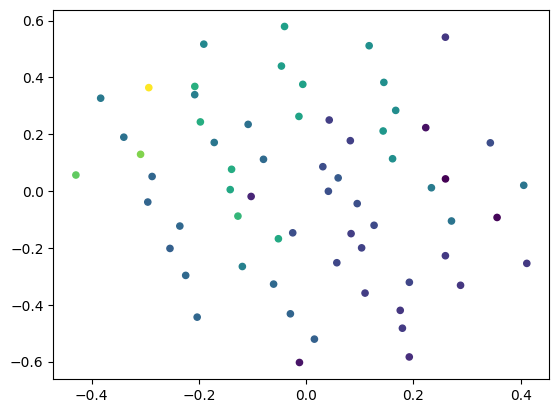

In [ ]:
x, y, s = rollout[-1].T

plt.scatter(x, y, c = s, s=20)

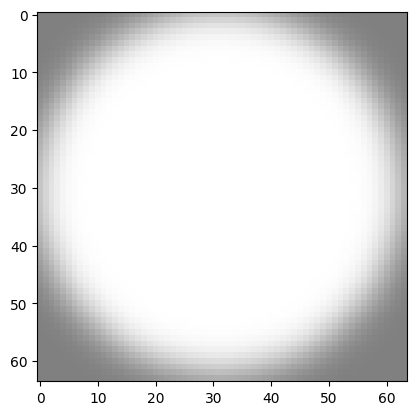

In [ ]:
plt.imshow(img_grid.cpu().numpy(), cmap='gray', alpha=0.5)

In [ ]:
# see all trainable parameters
for name, param in trainer.particle_system.named_parameters():
    if param.requires_grad:
        print(name,)

message_conv.nn.0.weight
message_conv.nn.0.bias
message_conv.nn.2.weight
message_conv.nn.2.bias
message_conv.lin.0.weight
message_conv.lin.0.bias
message_conv.lin.2.weight
message_conv.lin.2.bias
message_to_output_layer.weight
message_to_output_layer.bias
